Dataset Shape: (1143, 13)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9

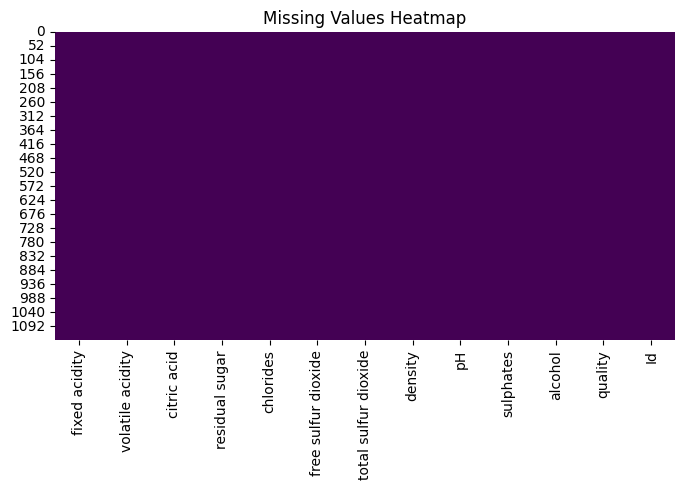

/tmp/ipykernel_1477/1361742022.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df, palette="viridis")


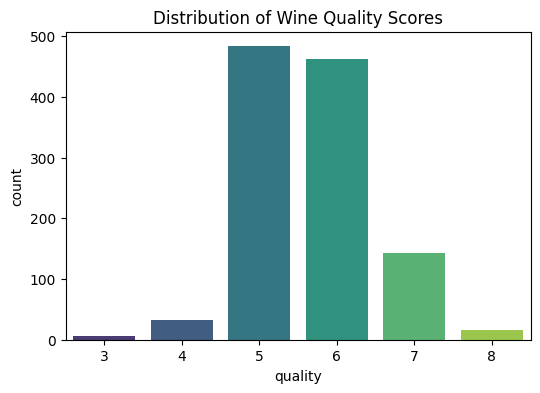

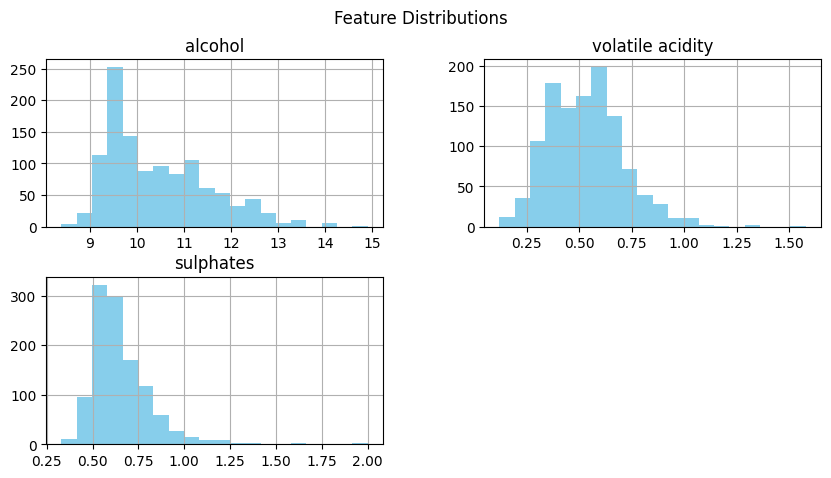

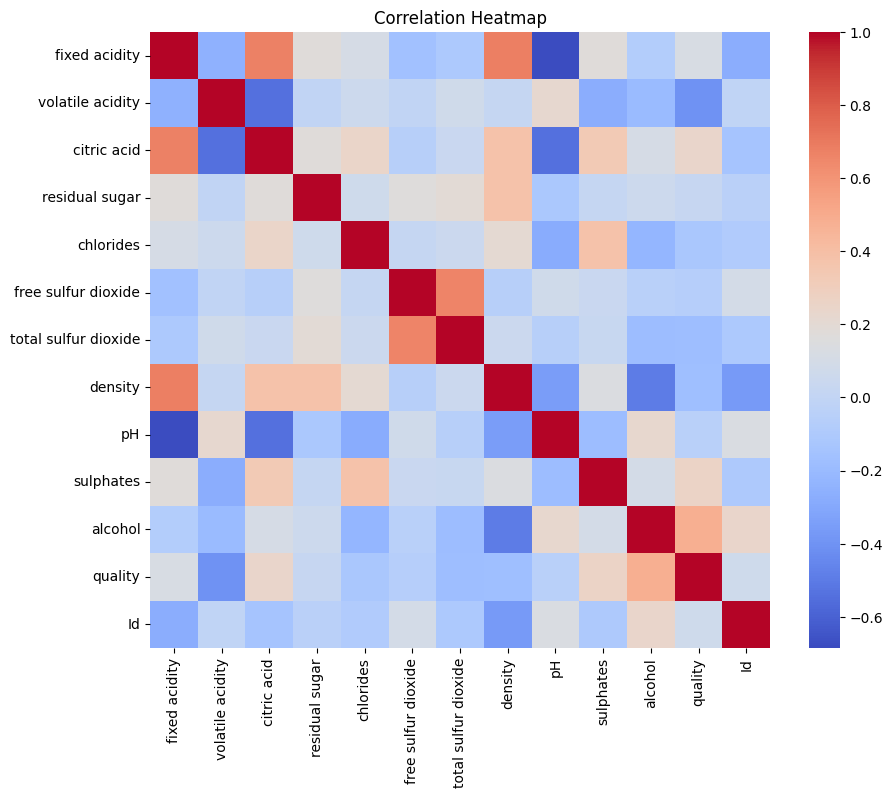

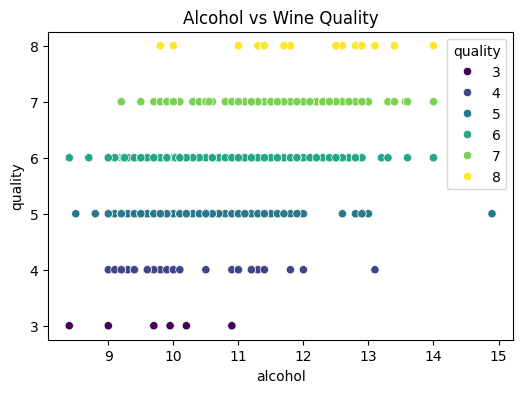

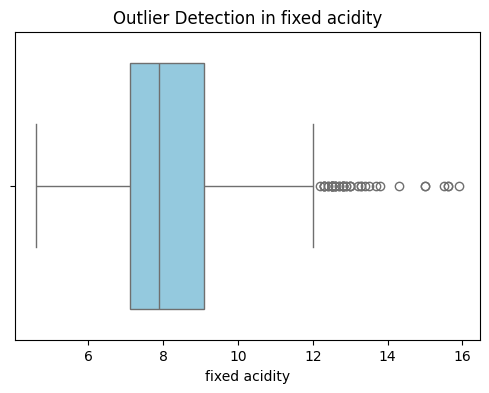

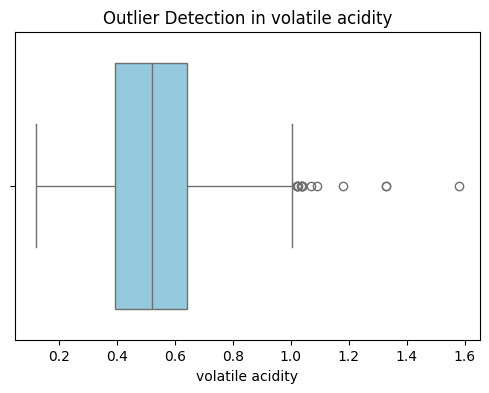

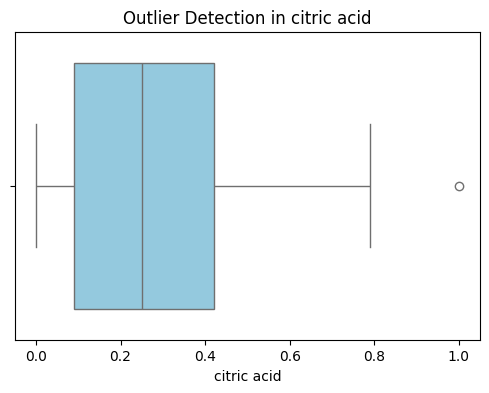

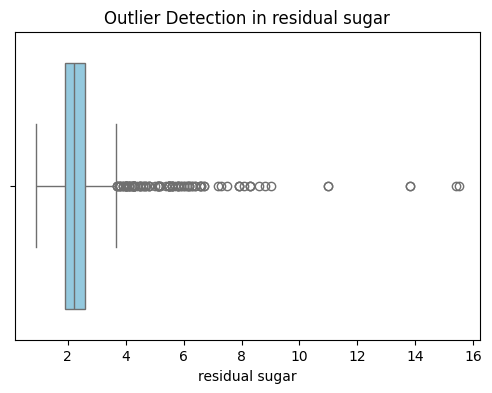

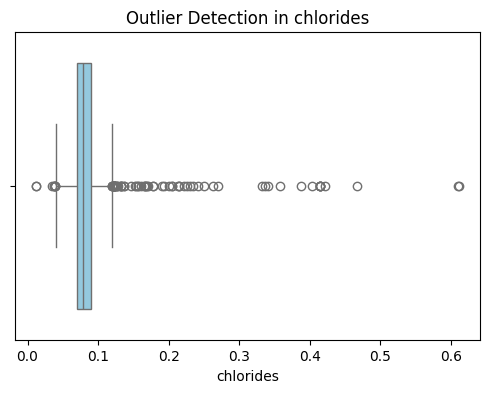

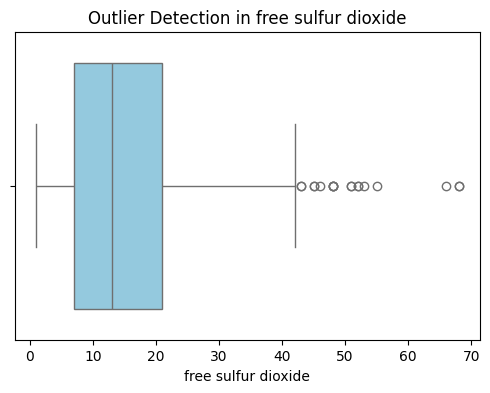

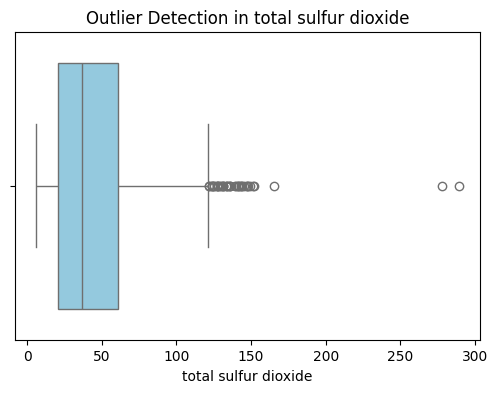

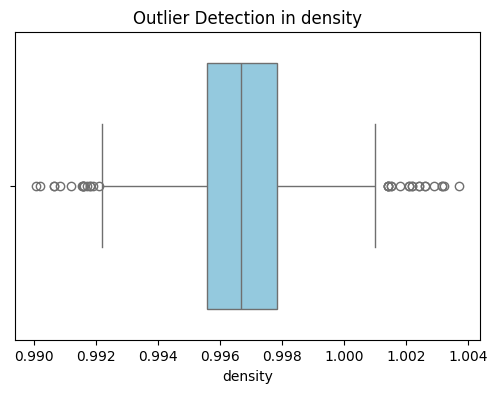

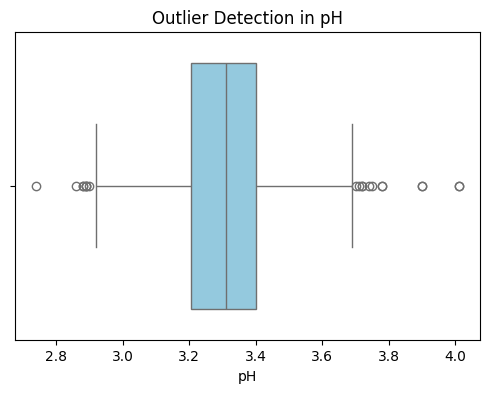

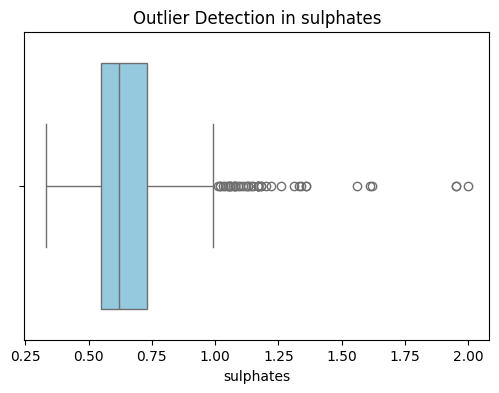

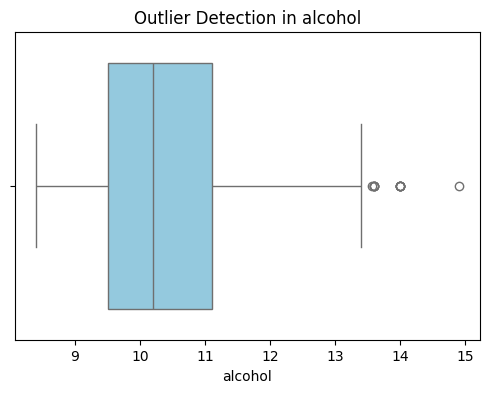

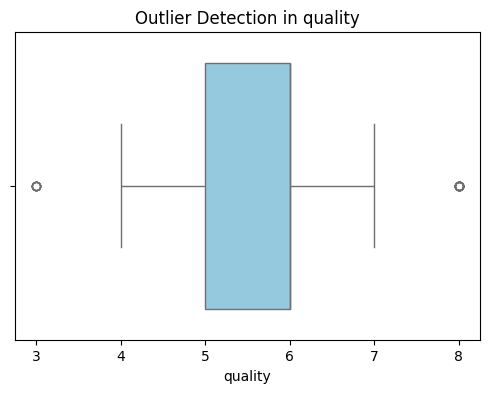

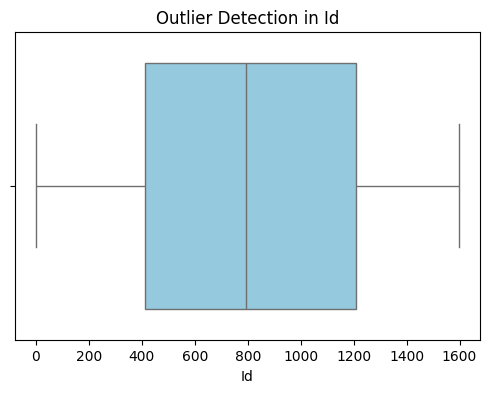


Outlier Counts per Numeric Column:
fixed acidity: 44
volatile acidity: 14
citric acid: 1
residual sugar: 110
chlorides: 77
free sulfur dioxide: 18
total sulfur dioxide: 40
density: 36
pH: 20
sulphates: 43
alcohol: 12
quality: 22
Id: 0


In [ ]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load dataset
df = pd.read_csv("WineQT.csv")   # replace with your file path
print("Dataset Shape:", df.shape)
print(df.head())

# 3. Basic info & summary
print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

# -------------------------------
# Missing Values
# -------------------------------
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Visualize missing values
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# -------------------------------
# Distribution of Wine Quality
# -------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x="quality", data=df, palette="viridis")
plt.title("Distribution of Wine Quality Scores")
plt.show()

# -------------------------------
# Histograms for Key Features
# -------------------------------
features = ["alcohol", "volatile acidity", "sulphates"]
df[features].hist(bins=20, figsize=(10,5), color="skyblue")
plt.suptitle("Feature Distributions")
plt.show()

# -------------------------------
# Correlation Heatmap
# -------------------------------
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# Scatterplot Example
# -------------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(x="alcohol", y="quality", data=df, hue="quality", palette="viridis")
plt.title("Alcohol vs Wine Quality")
plt.show()

# -------------------------------
# Outlier Detection (Boxplots)
# -------------------------------
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f"Outlier Detection in {col}")
    plt.show()

# -------------------------------
# Outlier Counts using IQR Method
# -------------------------------
def outlier_count(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

print("\nOutlier Counts per Numeric Column:")
for col in numeric_cols:
    print(f"{col}: {outlier_count(df[col])}")
